In [ ]:
from pyomo.environ import *
import pandas as pd
import numpy as np
import sys
from pyomo.opt import SolverFactory
import gurobipy as gp
import matplotlib.pyplot as plt
from pyomo.core.expr.visitor import identify_variables
import seaborn as sns
import os
from typing import Dict

from new_formulation.SingleRegionModel import SingleRegionModelNew
from new_formulation.OperationalSubProblem_independentScenario import OperationalSubProblem


# Functions

In [7]:
technology_mapping = {
    'Coal': 0,
    'CoalCCS': 1,
    'OCGT': 2,
    'CCGT': 3,
    'Diesel': 4,
    'Nuclear': 5,
    'PHES': 6,
    'Lithium': 7,
    'Wind_onshore': 8,
    'Wind_offshore': 9,
    'Solar': 10
}

generator_mapping = {
    'Coal': 0,
    'CoalCCS': 1,
    'OCGT': 2,
    'CCGT': 3,
    'Diesel': 4,
    'Nuclear': 5
}
        
storage_mapping = {
    'PHES': 0,
    'Lithium': 1
}

renewables_mapping = {
    'Wind_onshore': 0,
    'Wind_offshore': 1,
    'Solar': 2
}

ope_stage = {
    1:[0,1,2],
    2: [3,4,5,6,7,8,9,10,11]
}

inv_stage = {
    0:1,
    1:2,
    2:2,
    3:2,
    4:3,
    5:3,
    6:3,
    7:3,
    8:3,
    9:3,
    10:3,
    11:3,
    12:3
}
        
def get_ope_stage(node):
    for stage, nodes in ope_stage.items():
        if node in nodes:
            return stage
        
id_generator_mapping = {v: k for k, v in generator_mapping.items()}
id_storage_mapping = {v: k for k, v in storage_mapping.items()}
id_renewables_mapping = {v: k for k, v in renewables_mapping.items()}

In [8]:
def save_first_stage_deterministic_test(model):
    

    deterministic_x_acc = []
    for i in model.I:
        list_tmp = []
        for p in model.P:
            list_tmp.append(value(model.x_acc[p,i]))
        deterministic_x_acc.append(list_tmp)   

    return deterministic_x_acc

In [9]:
def create_solution_df(solution):
    int_to_tech = {v: k for k, v in technology_mapping.items()}
    rows = max(i for i, j in solution.keys()) + 1
    cols = max(j for i, j in solution.keys()) + 1
    array = np.zeros((rows, cols))

    for (i, j), value in solution.items():
        array[i, j] = value
        
    row_idx, col_idx = np.indices(array.shape)
    row_idx = row_idx.flatten()
    col_idx = col_idx.flatten()
    values = array.flatten()

    df = pd.DataFrame({
        'technologies': row_idx,
        'inv nodes': col_idx,
        'value': values
    })
    df['technologies'] = df['technologies'].map(int_to_tech)
    df['stage'] = df['inv nodes'].map(inv_stage)
    return df

In [10]:
def calculate_expectation_stages(df):
    probabilities = [1, 0.33, 0.33, 0.33, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11]
    df_tmp = df
    grouped = df.groupby('technologies')
    for _, groups in grouped:
        grp = groups['value']
        tmp = grp * probabilities 
        df_tmp.loc[tmp.index, 'value'] = tmp
    
    df_tmp = df_tmp.groupby(['technologies','stage'])['value'].sum()
    
    return df_tmp

In [11]:
def save_first_stage_deterministic(model):
    deterministic_x_inst = {}
    for (p,i), var in model.x_inst.items():
        deterministic_x_inst[p,i] = value(var)

    deterministic_x_acc = {}
    for (p,i), var in model.x_acc.items():
        deterministic_x_acc[p,i] = value(var)

    return [deterministic_x_acc, deterministic_x_inst]

# Functions

In [ ]:
technology_mapping = {
    'Coal': 0,
    'CoalCCS': 1,
    'OCGT': 2,
    'CCGT': 3,
    'Diesel': 4,
    'Nuclear': 5,
    'PHES': 6,
    'Lithium': 7,
    'Wind_onshore': 8,
    'Wind_offshore': 9,
    'Solar': 10
}

generator_mapping = {
    'Coal': 0,
    'CoalCCS': 1,
    'OCGT': 2,
    'CCGT': 3,
    'Diesel': 4,
    'Nuclear': 5
}
        
storage_mapping = {
    'PHES': 0,
    'Lithium': 1
}

renewables_mapping = {
    'Wind_onshore': 0,
    'Wind_offshore': 1,
    'Solar': 2
}

ope_stage = {
    1:[0,1,2],
    2: [3,4,5,6,7,8,9,10,11]
}

inv_stage = {
    0:1,
    1:2,
    2:2,
    3:2,
    4:3,
    5:3,
    6:3,
    7:3,
    8:3,
    9:3,
    10:3,
    11:3,
    12:3
}
        
def get_ope_stage(node):
    for stage, nodes in ope_stage.items():
        if node in nodes:
            return stage
        
id_generator_mapping = {v: k for k, v in generator_mapping.items()}
id_storage_mapping = {v: k for k, v in storage_mapping.items()}
id_renewables_mapping = {v: k for k, v in renewables_mapping.items()}

In [ ]:
def save_first_stage_deterministic_test(model):
    

    deterministic_x_acc = []
    for i in model.I:
        list_tmp = []
        for p in model.P:
            list_tmp.append(value(model.x_acc[p,i]))
        deterministic_x_acc.append(list_tmp)   

    return deterministic_x_acc

In [ ]:
def create_solution_df(solution):
    int_to_tech = {v: k for k, v in technology_mapping.items()}
    rows = max(i for i, j in solution.keys()) + 1
    cols = max(j for i, j in solution.keys()) + 1
    array = np.zeros((rows, cols))

    for (i, j), value in solution.items():
        array[i, j] = value
        
    row_idx, col_idx = np.indices(array.shape)
    row_idx = row_idx.flatten()
    col_idx = col_idx.flatten()
    values = array.flatten()

    df = pd.DataFrame({
        'technologies': row_idx,
        'inv nodes': col_idx,
        'value': values
    })
    df['technologies'] = df['technologies'].map(int_to_tech)
    df['stage'] = df['inv nodes'].map(inv_stage)
    return df

In [ ]:
def calculate_expectation_stages(df):
    probabilities = [1, 0.33, 0.33, 0.33, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11]
    df_tmp = df
    grouped = df.groupby('technologies')
    for _, groups in grouped:
        grp = groups['value']
        tmp = grp * probabilities 
        df_tmp.loc[tmp.index, 'value'] = tmp
    
    df_tmp = df_tmp.groupby(['technologies','stage'])['value'].sum()
    
    return df_tmp

In [ ]:
def save_first_stage_deterministic(model):
    deterministic_x_inst = {}
    for (p,i), var in model.x_inst.items():
        deterministic_x_inst[p,i] = value(var)

    deterministic_x_acc = {}
    for (p,i), var in model.x_acc.items():
        deterministic_x_acc[p,i] = value(var)

    return [deterministic_x_acc, deterministic_x_inst]

# Check variable number:
 
Check the numer of variables of the problem respect to the numebr of short term scenarios

In [ ]:
def display_num_variables():
    num_scenario = [10,20,30,40,50,60,70,80]
    num_vars_list = []
    num_constraints_list = []
    
    for i in num_scenario:
        model_instance = SingleRegionModel(num_short_term_scenarios=i)
        model = model_instance.get_model()
        num_vars = int(sum(1 for v in model.component_data_objects(Var)))
        num_constraints = int(sum(1 for v in model.component_data_objects(Constraint)))
        num_vars_list.append(num_vars)
        num_constraints_list.append(num_constraints)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

    
    ax1.plot(num_scenario, num_vars_list, marker='o', color='steelblue')
    ax1.set_title("Variables vs. scenarios")
    ax1.set_xlabel("number of scenario")
    ax1.set_ylabel("variables number")
    ax1.grid(True)

    
    ax2.plot(num_scenario, num_constraints_list, marker='s', color='darkorange')
    ax2.set_title("Constraint vs scenarios")
    ax2.set_xlabel("number of scenario")
    ax2.set_ylabel("constraints number")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()
    

In [ ]:
display_num_variables()

In [ ]:
def print_inv_ope_variables():
    
    num_scenario = [10,20,30,40,50,60,70,80]
    ope_list = []
    inv_list = []
    
    for i in num_scenario:
        
        model_instance = SingleRegionModel(num_short_term_scenarios=i)
        model = model_instance.get_model()
    
        investment_indexes = []
        operational_indexes = []
        for v in model.component_objects(Var):
            for index in v:
                if v.name == 'x_acc' or v.name == 'x_inst':
                    investment_indexes.append(index)
                else:
                    operational_indexes.append(index)

        num_inv = len(investment_indexes)
        num_ope = len(operational_indexes)
        
        inv_list.append(num_inv)
        ope_list.append(num_ope)
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)


    ax1.plot(num_scenario, inv_list, marker='o', color='steelblue')
    ax1.set_title("investment variables vs scenarios")
    ax1.set_xlabel("number of scenario")
    ax1.set_ylabel("Investment variables")
    ax1.grid(True)

    
    ax2.plot(num_scenario, ope_list, marker='s', color='darkorange')
    ax2.set_title("operational variables vs sceanrios")
    ax2.set_xlabel("number of scenario")
    ax2.set_ylabel("Operational variables")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()
    

In [ ]:
print_inv_ope_variables()

In [ ]:
model_instance = SingleRegionModel(num_short_term_scenarios=1)
model = model_instance.get_model()

inst = []
acc = []
for v in model.component_objects(Var):
    for index in v:
        if v.name == 'x_inst':
            inst.append(index)
        elif v.name == 'x_acc':
            acc.append(index)
        
print('Deterministic equivalent model investments variables')
print(f'x_inst varables: {len(inst)}')
print(f'x_acc varables: {len(acc)}')

In [ ]:
operational_nodes = 12
constraints = [model.technology_to_generator, model.technology_to_storage, model.technology_to_renewable]

const_var = set()

for indexed_constraint in constraints:
    for index in indexed_constraint:
        c = indexed_constraint[index]  
        vars = identify_variables(c.body)
        const_var.update(v.name for v in vars if v.name.startswith("x_acc"))

        
print(f'total number of variable passed from the investment problem to the operational problem: {len(const_var)}')
print(f'number of variable passed from the investment problem to the operational problem for a single node: {len(const_var)/operational_nodes}')

In [ ]:
import gc

scenarios = [1,3,5,10,15]
obj = []
for s in scenarios:
    model_instance = SingleRegionModel(num_short_term_scenarios=s)
    model = model_instance.get_model()
    opt = SolverFactory("gurobi_direct")
    results = opt.solve(model)
    obj.append(float(value(model.objective)))
    gc.collect()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(scenarios, obj, marker='o', linestyle='-', color='b')
plt.title('Objective Function Value vs. Number of Scenarios')
plt.xlabel('Number of Scenarios')
plt.ylabel('Objective Function Value')
plt.grid(True)
plt.xticks(scenarios)
plt.tight_layout()
plt.show()

# Solve a model

solve a model with a low scenario numerb for time reason and displaying investment variables values

In [12]:
scenarios = np.load('scenarios/scenarios.npy')
scenarios = scenarios[0:10]
model_instance = SingleRegionModelNew(short_term_scenarios=scenarios, num_short_term_scenarios=10)
model = model_instance.get_model()

In [13]:
opt = SolverFactory("gurobi_direct")
opt.options['Method'] = 2
results = opt.solve(model, tee=True)

Set parameter OutputFlag to value 1
Set parameter Method to value 2
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-1355U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
Method  2

Academic license 2643155 - for non-commercial use only - registered to g.___@campus.unimib.it
Optimize a model with 1325665 rows, 687527 columns and 4295414 nonzeros
Model fingerprint: 0x6b618f8e
Coefficient statistics:
  Matrix range     [5e-04, 2e+01]
  Objective range  [3e-03, 4e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e-01, 5e+04]
Presolve removed 2442 rows and 51024 columns (presolve time = 6s)...
Presolve removed 2922 rows and 51024 columns
Presolve time: 9.95s
Presolved: 1322743 rows, 636503 columns, 4239701 nonzeros

Ordering time: 2.42s

Barrier statistics:
 Dense cols : 110
 AA' NZ     : 6.989e+06
 Factor NZ  : 2.336e

In [14]:
print('Status:', results.solver.status)
print('Termination Condition:', results.solver.termination_condition)

Status: ok
Termination Condition: optimal


In [15]:
print('Objective function value: ', float(value(model.objective)))

Objective function value:  202740.8132211797


In [16]:
m = model
operational_cost = value(m.k * sum( m.pi_I[i] *
                    sum(  m.pi_n[n] *
                        sum( 
                            (
                                m.W[t] * m.H[t]
                            ) * (
                                sum(m.C_g[i, g] * m.p_G[g, t, i] for g in m.G)
                                + sum(m.C_se[s] * m.p_SEp[s, t, i] for s in m.S)
                                + m.C_shed_p * m.p_ShedP[t, i]
                            )
                            for t in m.T_n[n]
                        )
                        for n in m.N
                    )
                    for i in m.I
                ))

In [17]:
print('System costs:')
print(f'Total Cost: {value(model.objective)} mn£')
print(f'Investment cost: {value(model.objective) - operational_cost} mn£')
print(f'Operational cost: {operational_cost} mn£')

System costs:
Total Cost: 202740.8132211797 mn£
Investment cost: 121988.09409972095 mn£
Operational cost: 80752.71912145875 mn£


## Check if scenarios are independent

In [18]:
solution_check = save_first_stage_deterministic_test(model)

In [19]:
num_scenarios = 10
ope_node = 1
for s in range(num_scenarios):
    print(value(sum(((model.W[t] * model.H[t]) * ((sum((model.C_g[ope_node,g] * model.p_G[g,t,ope_node]) for g in model.G)) + (sum((model.C_se[s] * model.p_SEp[s,t, ope_node]) for s in model.S)) + (model.C_shed_p * model.p_ShedP[t, ope_node]))) for t in model.T_n[s])))

7621.657536073906
7196.451559045242
5855.440087539064
5986.4218688654455
6631.143178373559
6640.765958246795
7567.06447880131
6656.071167596988
6342.353426675999
6922.482069653837


In [20]:

sol = solution_check[ope_node]
for scen in range(10):
    scenario_set = np.load('scenarios/scenarios.npy')
    scenarios = scenario_set[scen]

    P_accg = sol[:6]
    P_accSE = sol[6:8]
    P_accr = sol[8:11]

    
        
    model_tmp_instance = OperationalSubProblem(scenarios, num_short_term_scenario=1)
    model_tmp = model_tmp_instance.get_model()
    opt = SolverFactory("gurobi_direct")
    opt.options['Method'] = 2
    
    
    for g in model_tmp.G:
        model_tmp.p_accG[g].fix(P_accg[g])
        for t in model_tmp.T:
            model_tmp.p_G[g,t].setub(P_accg[g])
    
    for s in model_tmp.S:
        model_tmp.p_accSE[s].fix(P_accSE[s])
        for t in model_tmp.T:
            model_tmp.p_SEm[s,t].setub(P_accSE[s])
            model_tmp.p_SEp[s,t].setub(P_accSE[s])
            model_tmp.q_SE[s,t].setub(P_accSE[s] * model_tmp.gamma_se[s])
    
        

    
    for r in model_tmp.R:
        model_tmp.p_accR[r].fix(P_accr[r])
    
    model_tmp.mu_dp.set_value(model.mu_dp[ope_node])
    model_tmp.mu_e.set_value((model.mu_e[ope_node]))
    

    result = opt.solve(model_tmp)
    
    
    if result.solver.termination_condition == TerminationCondition.infeasible:
        print('infeasible at index', index)
    else:
        ope_value = float(value(model_tmp.objective))
        print(ope_value)

    for var in model_tmp.component_data_objects(Var, active=True):
        var.unfix()
        var.value = None

7621.6575360739025
7196.451559045241
5855.440087539062
5986.421868865442
6631.143178373562
6640.765958246798
7567.064478801308
6656.071167596987
6342.353426675998
6922.482069653838


# Investments variables

In [21]:
investment_solution = save_first_stage_deterministic(model)[1]
investment_solution_df = create_solution_df(investment_solution)
expected_investments = calculate_expectation_stages(investment_solution_df).reset_index(name="value")

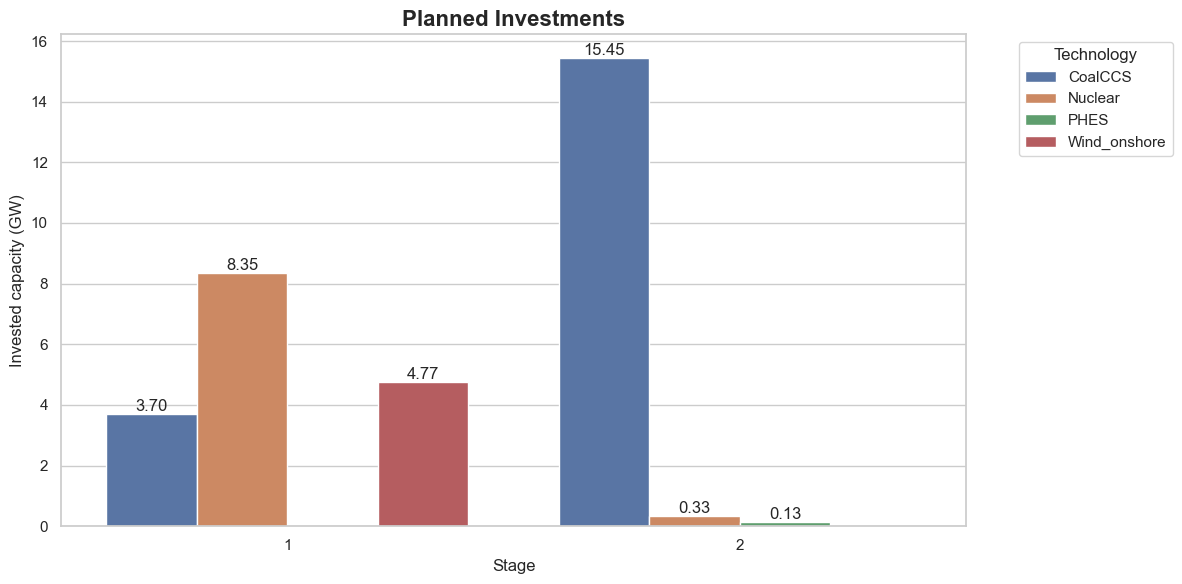

In [22]:
df_filtered = expected_investments[expected_investments["stage"].isin([1, 2])]
tech_with_investment = df_filtered.groupby("technologies")["value"].sum()
tech_with_investment = tech_with_investment[tech_with_investment > 0].index
df_filtered = df_filtered[df_filtered["technologies"].isin(tech_with_investment)]


sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df_filtered,
    x="stage",
    y="value",
    hue="technologies"
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.2f}",
                    (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=12)

plt.title("Planned Investments", fontsize=16, fontweight="bold")
plt.ylabel("Invested capacity (GW)")
plt.xlabel("Stage")

plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

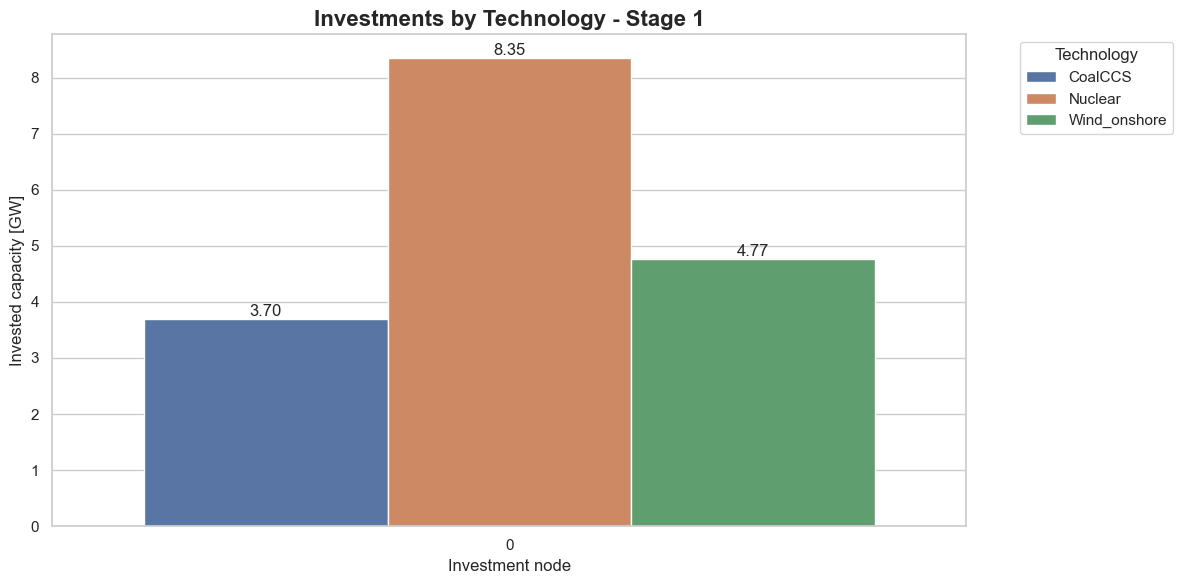

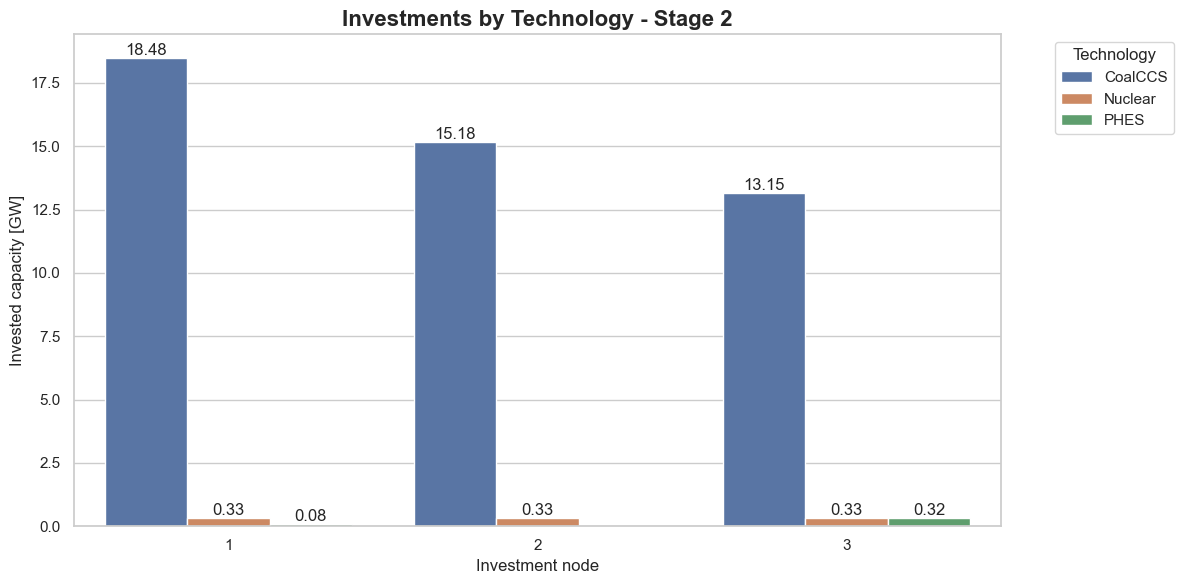

In [23]:
index_to_tech = {v: k for k, v in technology_mapping.items()}

data = []
for (tech_idx, node), var in model.x_inst.items():
    tech_name = index_to_tech[tech_idx]
    data.append({'Technology': tech_name, 'Node': node, 'Value': var.value })

df = pd.DataFrame(data)

stage_mapping = {
    1: [0],            
    2: [1, 2, 3]
}

sns.set_theme(style="whitegrid")


for stage, nodes in stage_mapping.items():
    df_stage = df[df["Node"].isin(nodes)].copy()

    
    df_stage = df_stage[df_stage["Value"] > 0]

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=df_stage,
        x="Node",
        y="Value",
        hue="Technology",
        dodge=True
    )

    
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{h:.2f}",
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=12)

    plt.title(f"Investments by Technology - Stage {stage}", fontsize=16, fontweight="bold")
    plt.ylabel("Invested capacity [GW]")
    plt.xlabel("Investment node")
    plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [24]:
data = []
for (tech_idx, node), var in model.x_inst.items():
    tech_name = index_to_tech[tech_idx]
    data.append({'stage': inv_stage[node], 'inv_node': node, 'technology': tech_name,'installed capacity': var.value })
    
inst_df = pd.DataFrame(data).sort_values(by=['stage', 'inv_node'])
inst_df.to_csv('results/X_inst_results_newFormulation.csv')
inst_df

,stage,inv_node,technology,installed capacity
0,1,0,Coal,0.000000
13,1,0,CoalCCS,3.702923
26,1,0,OCGT,0.000000
39,1,0,CCGT,0.000000
52,1,0,Diesel,0.000000
...,...,...,...,...
90,3,12,PHES,0.000000
103,3,12,Lithium,0.000000
116,3,12,Wind_onshore,0.000000
129,3,12,Wind_offshore,0.000000


In [25]:
data = []
for (tech_idx, node), var in model.x_acc.items():
    tech_name = index_to_tech[tech_idx]
    data.append({'stage': get_ope_stage(node), 'ope_node': node, 'technology': tech_name,'accumulated capacity': var.value })
    
acc_df = pd.DataFrame(data).sort_values(by=['stage', 'ope_node'])
acc_df.to_csv('results/X_acc_results_newFormulation.csv')
acc_df

,stage,ope_node,technology,accumulated capacity
0,1,0,Coal,12.599991
12,1,0,CoalCCS,5.702923
24,1,0,OCGT,7.200000
36,1,0,CCGT,22.499991
48,1,0,Diesel,4.500000
...,...,...,...,...
83,2,11,PHES,3.964191
95,2,11,Lithium,0.500000
107,2,11,Wind_onshore,23.281340
119,2,11,Wind_offshore,13.405937


# Operational variables

In [26]:
colors = sns.color_palette("tab20", 11)
operational_node = 3
time_slice = 0

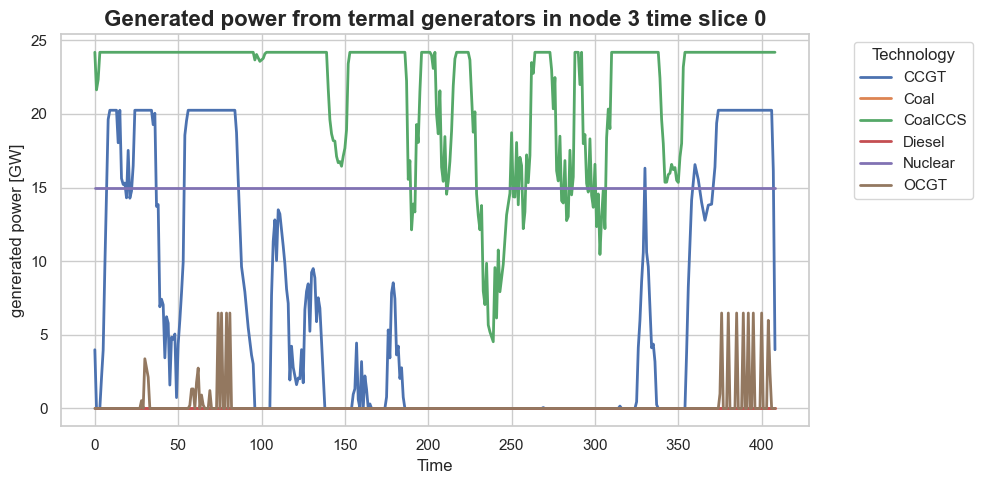

In [27]:
index_to_tech = {v: k for k, v in generator_mapping.items()}
data = []
for (tech_idx, time, node), var in model.p_G.items():
    tech_name = index_to_tech[tech_idx]  
    data.append({'Technology': tech_name, 'Node': node, 'Value': var.value  , 'Time':time})


df = pd.DataFrame(data)
df = df[df['Node'] == operational_node]

pivot_df = df.pivot(index='Time', columns='Technology', values='Value')
pivot_df = pivot_df.loc[model.T_n[time_slice]]


pivot_df.plot(figsize=(10, 5), linewidth=2)
plt.title(f'Generated power from termal generators in node {operational_node} time slice {time_slice}', fontsize=16, fontweight="bold")
plt.xlabel('Time', fontsize=12)
plt.ylabel('genrerated power [GW]', fontsize=12)
plt.grid(True)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

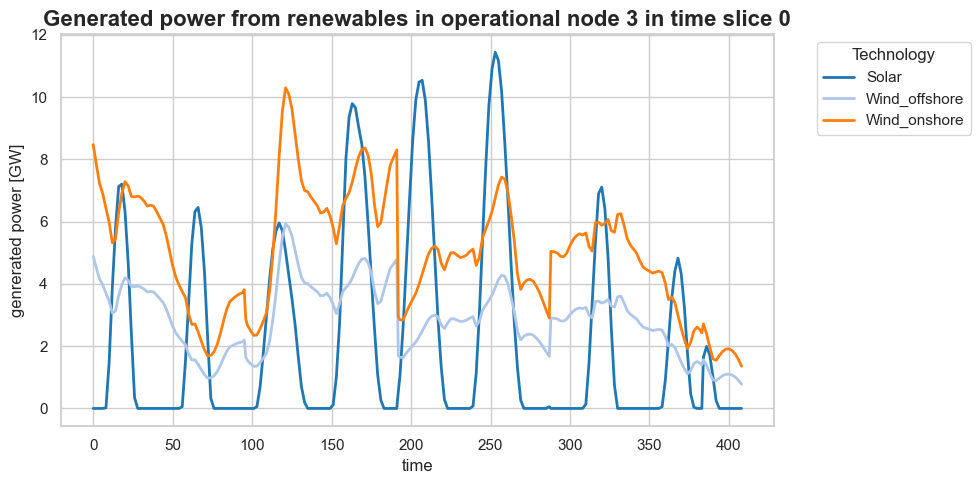

In [28]:
index_to_tech = {v: k for k, v in generator_mapping.items()}
index_to_tech_r = {v: k for k, v in renewables_mapping.items()}


data = []
for (tech_idx, time), var in model.R_r.items():
    tech_name = index_to_tech_r[tech_idx]
    data.append({'Technology': tech_name, 'Value': var * model.p_accR[tech_idx, node].value, 'Time':time})

df = pd.DataFrame(data)

pivot_df = df.pivot(index='Time', columns='Technology', values='Value')
pivot_df = pivot_df.loc[model.T_n[time_slice]]

pivot_df.plot(figsize=(10,5), linewidth=2, color=colors)
plt.title(f'Generated power from renewables in operational node {operational_node} in time slice {time_slice}', fontsize=16, fontweight="bold")
plt.xlabel('time')
plt.ylabel('genrerated power [GW]')
plt.grid(True)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

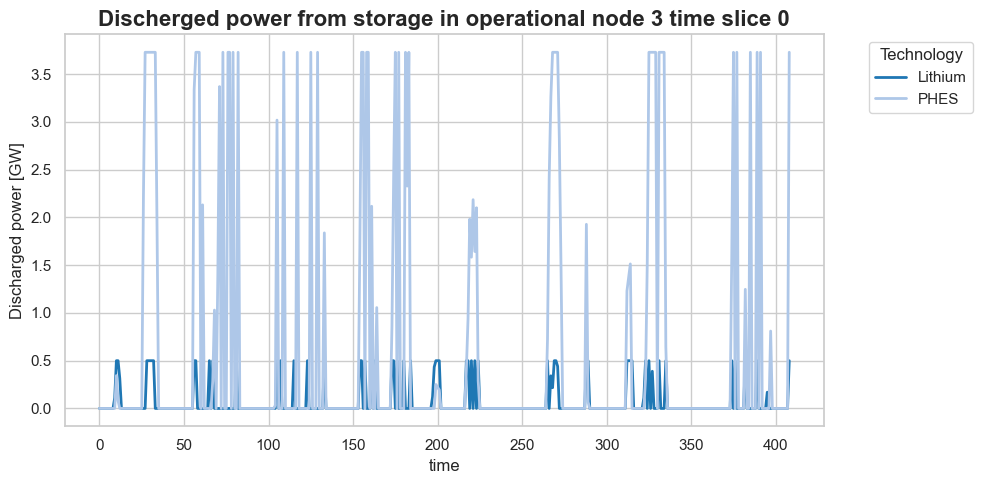

In [29]:
index_to_tech = {v: k for k, v in storage_mapping.items()}


data_m = []
for (tech_idx, time, node), var in model.p_SEm.items():
    if node == operational_node:
        tech_name = index_to_tech[tech_idx]
        data_m.append({'Technology': tech_name, 'Time': time, 'Value': var.value})
        
df_m = pd.DataFrame(data_m)
pivot_m = df_m.pivot(index='Time', columns='Technology', values='Value')
pivot_m = pivot_m.loc[model.T_n[time_slice]]

pivot_m.plot(figsize=(10,5), linewidth=2, color=colors)
plt.title(f'Discherged power from storage in operational node {operational_node} time slice {time_slice}', fontsize=16, fontweight="bold")
plt.xlabel('time')
plt.ylabel('Discharged power [GW]')
plt.grid(True)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

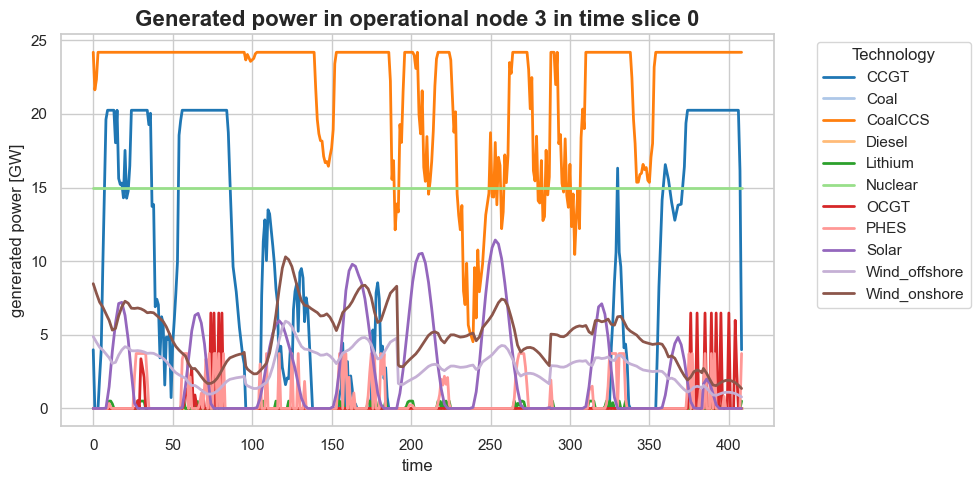

In [30]:
index_to_tech = {v: k for k, v in generator_mapping.items()}
index_to_tech_r = {v: k for k, v in renewables_mapping.items()}
index_to_tech_s = {v: k for k, v in storage_mapping.items()}


data = []
for (tech_idx, time, node), var in model.p_G.items():
    tech_name = index_to_tech[tech_idx]  
    data.append({'Technology': tech_name, 'Node': node, 'Value': var.value  , 'Time':time})

for (tech_idx, time), var in model.R_r.items():
    tech_name = index_to_tech_r[tech_idx]
    for node in range(12):
        data.append({'Technology': tech_name,'Node':node, 'Value': var * model.p_accR[tech_idx, node].value, 'Time':time})
        
for (tech_idx, time, node), var in model.p_SEm.items():
    tech_name = index_to_tech_s[tech_idx]
    data.append({'Technology': tech_name, 'Node':node,'Time': time, 'Value': var.value})

df = pd.DataFrame(data)
df = df[df['Node'] == operational_node]

pivot_df = df.pivot(index='Time', columns='Technology', values='Value')
pivot_df = pivot_df.loc[model.T_n[time_slice]]

pivot_df.plot(figsize=(10,5), linewidth=2, color=colors)
plt.title(f'Generated power in operational node {operational_node} in time slice {time_slice}', fontsize=16, fontweight="bold")
plt.xlabel('time')
plt.ylabel('genrerated power [GW]')
plt.grid(True)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



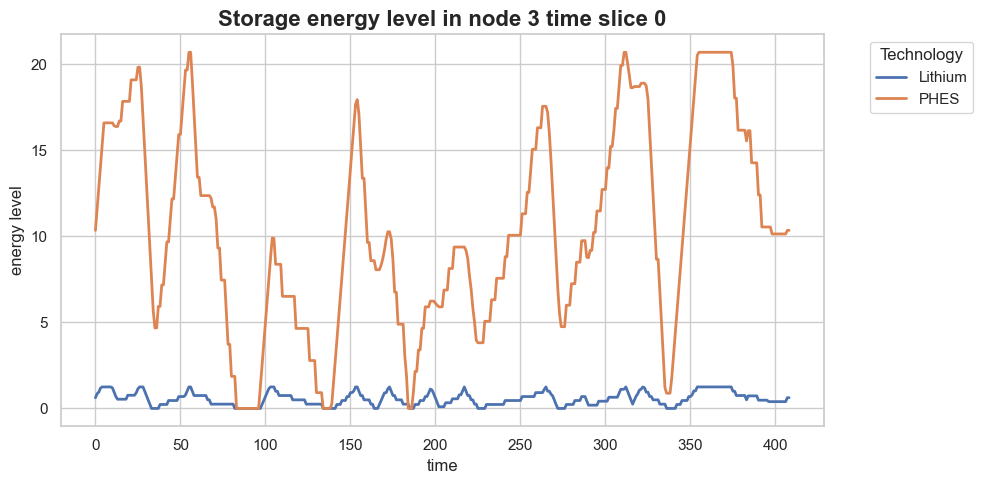

In [31]:
index_to_tech = {v: k for k, v in storage_mapping.items()}

data = []
for (tech_idx, time, node), var in model.q_SE.items():
    tech_name = index_to_tech[tech_idx]  
    data.append({'Technology': tech_name, 'Node': node, 'Value': var.value, 'Time':time})


df = pd.DataFrame(data)
df = df[df['Node'] == operational_node]
pivot_df = df.pivot(index='Time', columns='Technology', values='Value')
pivot_df = pivot_df.loc[model.T_n[time_slice]]

pivot_df.plot(figsize=(10,5), linewidth=2)
plt.title(f'Storage energy level in node {operational_node} time slice {time_slice}', fontsize=16, fontweight="bold")
plt.xlabel('time', fontsize=12)
plt.ylabel('energy level', fontsize=12)
plt.grid(True)
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

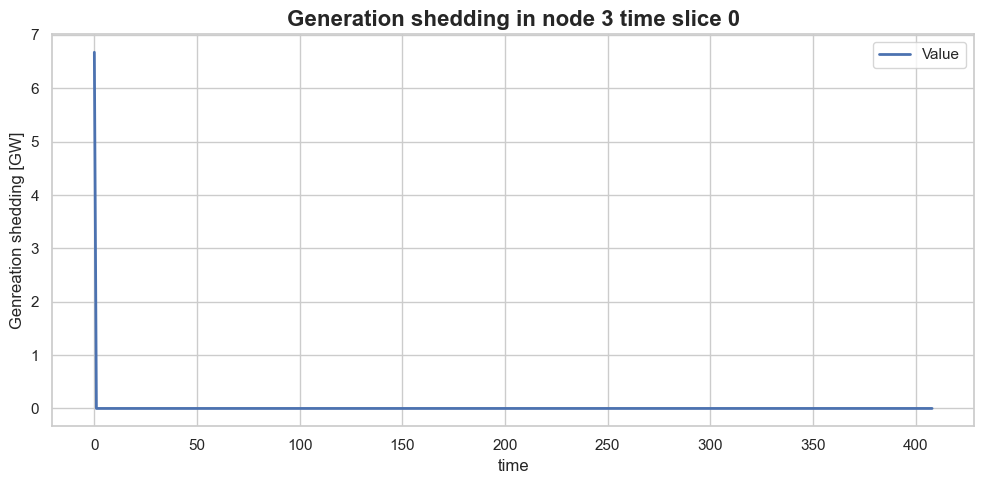

In [32]:
data = []
for (time, node), var in model.p_GshedP.items():
    data.append({'Value': var.value, 'Time':time, 'Node':node})

df = pd.DataFrame(data)
df = df[df['Node'] == operational_node]
df = df.set_index('Time')
df = df.loc[model.T_n[time_slice]]

df = df.drop(['Node'], axis = 1)


df.plot(figsize=(10,5), linewidth=2)
plt.title(f'Generation shedding in node {operational_node} time slice {time_slice}', fontsize=16, fontweight="bold")
plt.xlabel('time', fontsize=12)
plt.ylabel('Genreation shedding [GW]', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

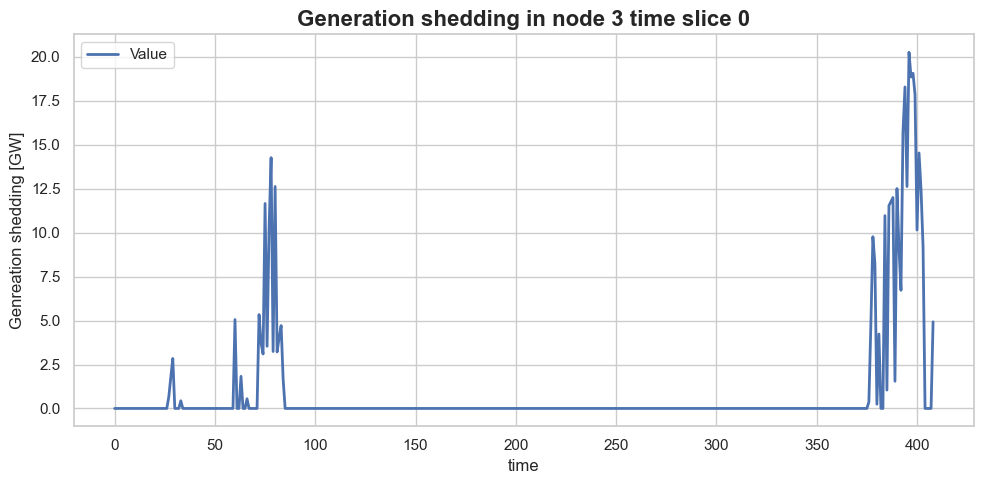

In [33]:

data = []
for (time, node), var in model.p_ShedP.items():
    
    data.append({'Value': var.value, 'Time':time, 'Node':node})


df = pd.DataFrame(data)
df = df[df['Node'] == operational_node]
df = df.set_index('Time')
df = df.loc[model.T_n[time_slice]]

df = df.drop(['Node'], axis = 1)

df.plot(figsize=(10,5), linewidth=2)
plt.title(f'Generation shedding in node {operational_node} time slice {time_slice}', fontsize=16, fontweight="bold")
plt.xlabel('time', fontsize=12)
plt.ylabel('Genreation shedding [GW]', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

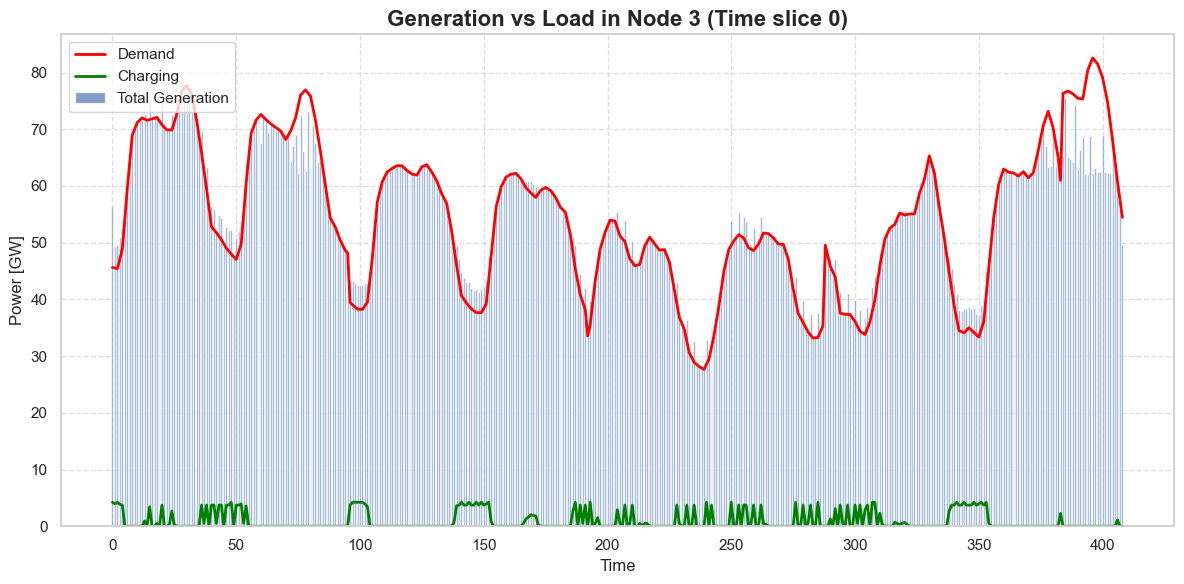

In [34]:
index_to_tech = {v: k for k, v in generator_mapping.items()}
index_to_tech_r = {v: k for k, v in renewables_mapping.items()}
index_to_tech_s = {v: k for k, v in storage_mapping.items()}


data = []
for (tech_idx, time, node), var in model.p_G.items():
    tech_name = index_to_tech[tech_idx]  
    data.append({'Technology': tech_name, 'Node': node, 'Value': var.value  , 'Time':time})

for (tech_idx, time), var in model.R_r.items():
    tech_name = index_to_tech_r[tech_idx]
    for node in range(12):
        data.append({'Technology': tech_name,'Node':node, 'Value': var * model.p_accR[tech_idx, node].value, 'Time':time})
        
for (tech_idx, time, node), var in model.p_SEm.items():
    tech_name = index_to_tech_s[tech_idx]
    data.append({'Technology': tech_name, 'Node':node,'Time': time, 'Value': var.value})
    
demand = []
for time, var in model.P_DP.items():
    demand.append({'Demand': var * (model.mu_dp[operational_node]*-1), 'Time':time})
    
charging = []
for (tech_idx, time, node), var in model.p_SEp.items():
    tech_name = index_to_tech_s[tech_idx]
    charging.append({'Technology': tech_name, 'Node':node,'Time': time, 'Value': var.value})

demand_df = pd.DataFrame(demand)
demand_df = demand_df.set_index('Time')
demand_df = demand_df.loc[model.T_n[time_slice]]

charging_df = pd.DataFrame(charging)
charging_df = charging_df[charging_df['Node'] == operational_node]
charging_df = charging_df.pivot(index='Time', columns='Technology', values='Value')
charging_df = charging_df.loc[model.T_n[time_slice]]
total_charging = charging_df.sum(axis=1)

df = pd.DataFrame(data)
df = df[df['Node'] == operational_node]
pivot_df = df.pivot(index='Time', columns='Technology', values='Value')
pivot_df = pivot_df.loc[model.T_n[time_slice]]
total_generation = pivot_df.sum(axis=1)


fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(total_generation.index, total_generation.values, label="Total Generation", alpha=0.7)

ax.plot(demand_df.index, demand_df.values, color="red", linewidth=2, label="Demand")

ax.plot(total_charging.index, total_charging.values, color="green", linewidth=2, label="Charging")

ax.set_title(f"Generation vs Load in Node {operational_node} (Time slice {time_slice})",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Power [GW]", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()